# Testing Nicolas's conditional sampling

In [1]:
# Set path to use this version of cirkit
import os
import sys
sys.path.insert(0, "../")

In [2]:
from cirkit.backend.torch.queries import SamplingQuery
from cirkit.symbolic.circuit import Circuit, Scope
from cirkit.symbolic.layers import GaussianLayer, SumLayer, HadamardLayer
from cirkit.templates import utils

In [3]:
def build_symbolic_circuit() -> Circuit:
    # This parametrizes the mixture weights such that they add up to one.
    weight_factory = utils.parameterization_to_factory(utils.Parameterization(
        activation='softmax',   # Parameterize the sum weights by using a softmax activation
        initialization='uniform' # Initialize the sum weights by sampling from a standard normal distribution
    ))

    # We introduce one more mixture than in the original model
    # Again, SGD/Adam is not the best way to fit a (shallow) Gaussian mixture model
    units = 1
    
    # Define the layers
    gx0 = GaussianLayer(Scope((0,)), units)
    gx1 = GaussianLayer(Scope((0,)), units)
    gx2 = GaussianLayer(Scope((0,)), units)
    gx3 = GaussianLayer(Scope((0,)), units)
    
    gy0 = GaussianLayer(Scope((1,)), units)
    gy1 = GaussianLayer(Scope((1,)), units)
    gy2 = GaussianLayer(Scope((1,)), units)
    gy3 = GaussianLayer(Scope((1,)), units)
    
    gz0 = GaussianLayer(Scope((2,)), units)
    gz1 = GaussianLayer(Scope((2,)), units)

    prod_bottom_left_0 = HadamardLayer(num_input_units=units, arity=2)
    prod_bottom_left_1 = HadamardLayer(num_input_units=units, arity=2)
    prod_bottom_right_0 = HadamardLayer(num_input_units=units, arity=2)
    prod_bottom_right_1 = HadamardLayer(num_input_units=units, arity=2)

    prod_top_0 = HadamardLayer(num_input_units=units, arity=2)
    prod_top_1 = HadamardLayer(num_input_units=units, arity=2)

    sum_bottom_left = SumLayer(units, 1, 2, weight_factory=weight_factory)
    sum_bottom_right = SumLayer(units, 1, 2, weight_factory=weight_factory)
    sum_top = SumLayer(units, 1, 2, weight_factory=weight_factory)

    return Circuit(
        layers=[
            gx0, gx1, gx2, gx3,
            gy0, gy1, gy2, gy3,
            gz0, gz1,
            prod_bottom_left_0, prod_bottom_left_1,
            prod_bottom_right_0, prod_bottom_right_1,
            prod_top_0, prod_top_1,
            sum_bottom_left, sum_bottom_right,
            sum_top
        ],  # Layers that appear in the circuit (i.e. nodes in the graph)
        in_layers={  # Connections between layers (i.e. edges in the graph as an adjacency list)
            gx0: [],
            gx1: [],
            gx2: [],
            gx3: [],
            gy0: [],
            gy1: [],
            gy2: [],
            gy3: [],
            gz0: [],
            gz1: [],
            prod_bottom_left_0: [gx0, gy0],
            prod_bottom_left_1: [gx1, gy1],
            prod_bottom_right_0: [gx2, gy2],
            prod_bottom_right_1: [gx3, gy3],
            sum_bottom_left: [prod_bottom_left_0, prod_bottom_left_1],
            sum_bottom_right: [prod_bottom_right_0, prod_bottom_right_1],
            prod_top_0: [sum_bottom_left, gz0],
            prod_top_1: [sum_bottom_right, gz1],
            sum_top: [prod_top_0, prod_top_1],
        },
        outputs=[sum_top]  # Nodes that are returned by the circuit
    )

In [4]:
symbolic_circuit = build_symbolic_circuit()

# Print which structural properties the circuit satisfies
print(f'Structural properties:')
print(f'  - Smoothness: {symbolic_circuit.is_smooth}')
print(f'  - Decomposability: {symbolic_circuit.is_decomposable}')
print(f'  - Structured-decomposability: {symbolic_circuit.is_structured_decomposable}')

Structural properties:
  - Smoothness: True
  - Decomposability: True
  - Structured-decomposability: True


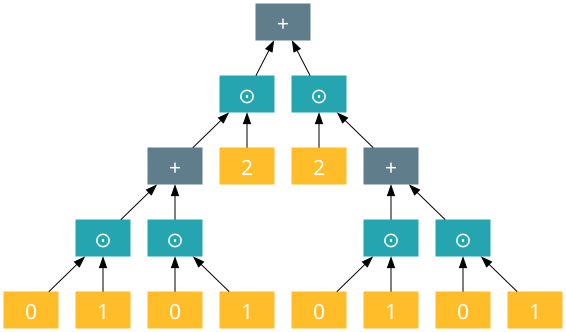

In [5]:
from cirkit.symbolic.io import plot_circuit

plot_circuit(symbolic_circuit)

In [6]:
from cirkit.pipeline import PipelineContext, compile

# Instantiate the pipeline context
ctx = PipelineContext(
    backend='torch',  # Choose PyTorch as compilation backend
    # ---- Use the evaluation semiring (R, +, x), where + is the numerically stable LogSumExp and x is the sum ---- #
    semiring='lse-sum',
    # ------------------------------------------------------------------------------------------------------------- #
    fold=False,
    optimize=False
)

with ctx:  # Compile the circuits computing log |c(X)|
    circuit = compile(symbolic_circuit)

In [7]:
print(circuit)

TorchCircuit(
  (0): TorchGaussianLayer(
    folds: 1  variables: 1  output-units: 1
    input-shape: (1, 1, -1, 1)
    output-shape: (1, -1, 1)
    (mean): TorchParameter(
      shape: (1, 1)
      (0): TorchTensorParameter(output-shape: (1, 1))
    )
    (stddev): TorchParameter(
      shape: (1, 1)
      (0): TorchTensorParameter(output-shape: (1, 1))
      (1): TorchScaledSigmoidParameter(
        input-shapes: [(1, 1)]
        output-shape: (1, 1)
      )
    )
  )
  (1): TorchGaussianLayer(
    folds: 1  variables: 1  output-units: 1
    input-shape: (1, 1, -1, 1)
    output-shape: (1, -1, 1)
    (mean): TorchParameter(
      shape: (1, 1)
      (0): TorchTensorParameter(output-shape: (1, 1))
    )
    (stddev): TorchParameter(
      shape: (1, 1)
      (0): TorchTensorParameter(output-shape: (1, 1))
      (1): TorchScaledSigmoidParameter(
        input-shapes: [(1, 1)]
        output-shape: (1, 1)
      )
    )
  )
  (2): TorchGaussianLayer(
    folds: 1  variables: 1  output-un

In [8]:
sampling_query = SamplingQuery(circuit)
_, samples = sampling_query(num_samples=256) 

In [9]:
import matplotlib.pyplot as plt

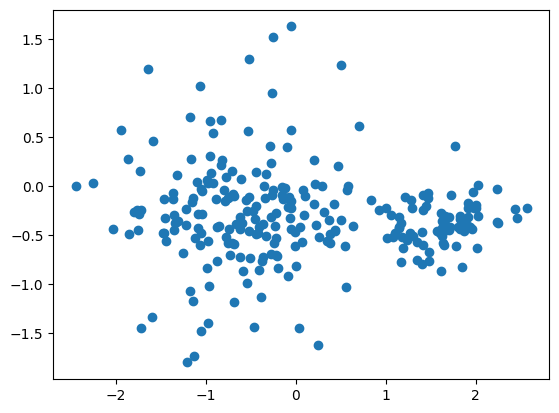

In [10]:
plt.scatter(*samples[:, 1:].T)
# samples.shape

In [ ]:
#     # select the variables used as evidence
#     evidence_vars = torch.full_like(sample, 0)
#     evidence_vars[:, sample.shape[1] // 2:] = 1
#     evidence_vars = evidence_vars.bool()
#     evidence = sample.clone()
#     evidence[~evidence_vars] = 0

#     _, variation = sampling_query(
#         num_samples=4,
#         x=evidence.to(circuit.device), 
#         evidence_vars=evidence_vars.bool().to(circuit.device)
#     )

# Comparison against cirkit independent conditional sampling

In [ ]:
import torch
import torch.distributions as D

class SimpleCircuit3D():
    def __init__(self,
                 weights_1: torch.Tensor,
                 weights_2: torch.Tensor,
                 weights_3: torch.Tensor,
                 means_x: torch.Tensor,
                 means_y: torch.Tensor,
                 means_z: torch.Tensor,
                 variances_x: torch.Tensor,
                 variances_y: torch.Tensor,
                 variances_z: torch.Tensor):

        # Define sum weights in the circuit
        self.weights_1 = self._validate_prob_vector("weights_1", weights_1, expected_len=2)
        self.weights_2 = self._validate_prob_vector("weights_2", weights_2, expected_len=2)
        self.weights_3 = self._validate_prob_vector("weights_3", weights_3, expected_len=2)

        # Define sum units as categorical distributions
        self.sum_1 = D.Categorical(weights_1)
        self.sum_2 = D.Categorical(weights_2)
        self.sum_3 = D.Categorical(weights_3)

        # Define Gaussian parameters in the circuit
        self.means_x = self._validate_length("means_x", means_x, expected_len=4)
        self.means_y = self._validate_length("means_y", means_y, expected_len=4)
        self.means_z = self._validate_length("means_z", means_z, expected_len=2)

        self.variances_x = self._validate_positive_vector("variances_x", variances_x, expected_len=4)
        self.variances_y = self._validate_positive_vector("variances_y", variances_y, expected_len=4)
        self.variances_z = self._validate_positive_vector("variances_z", variances_z, expected_len=2)

        # Define input distributions over x using Gaussian parameters
        self.p1 = D.Normal(loc=means_x[0], scale=torch.sqrt(variances_x[0]))
        self.p2 = D.Normal(loc=means_x[1], scale=torch.sqrt(variances_x[1]))
        self.p3 = D.Normal(loc=means_x[2], scale=torch.sqrt(variances_x[2]))
        self.p4 = D.Normal(loc=means_x[3], scale=torch.sqrt(variances_x[3]))

        # Define input distributions over y using Gaussian parameters
        self.q1 = D.Normal(loc=means_y[0], scale=torch.sqrt(variances_y[0]))
        self.q2 = D.Normal(loc=means_y[1], scale=torch.sqrt(variances_y[1]))
        self.q3 = D.Normal(loc=means_y[2], scale=torch.sqrt(variances_y[2]))
        self.q4 = D.Normal(loc=means_y[3], scale=torch.sqrt(variances_y[3]))

        # Define input distributions over z using Gaussian parameters
        self.r1 = D.Normal(loc=means_z[0], scale=torch.sqrt(variances_z[0]))
        self.r2 = D.Normal(loc=means_z[1], scale=torch.sqrt(variances_z[1]))

        # Organize components for easier access
        self.r_indices = {0: self.r1, 1: self.r2}

        self.p_indices_left = {0: self.p1, 1: self.p2}
        self.p_indices_right = {0: self.p3, 1: self.p4}
        self.p_indices = {0: self.p_indices_left, 1: self.p_indices_right}

        self.q_indices_left = {0: self.q1, 1: self.q2}
        self.q_indices_right = {0: self.q3, 1: self.q4}
        self.q_indices = {0: self.q_indices_left, 1: self.q_indices_right}

        self.bottom_sum_indices = {0: self.sum_2, 1: self.sum_3}
    
    def _to_tensor(self, x, name):
        t = torch.as_tensor(x)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        return t

    def _validate_prob_vector(self, name, x, expected_len, atol=1e-6):
        t = self._to_tensor(x, name)
        if t.dim() != 1 or t.numel() != expected_len:
            raise ValueError(f"{name} must be a 1-D tensor of length {expected_len}.")
        if (t < 0).any():
            raise ValueError(f"{name} must be non-negative.")
        if not torch.isclose(t.sum(), torch.tensor(1.0), atol=atol):
            raise ValueError(f"{name} must sum to 1 (within atol={atol}).")
        return t

    def _validate_length(self, name, x, expected_len):
        t = self._to_tensor(x, name)
        if t.dim() != 1 or t.numel() != expected_len:
            raise ValueError(f"{name} must be a 1-D tensor of length {expected_len}.")
        return t

    def _validate_positive_vector(self, name, x, expected_len):
        t = self._validate_length(name, x, expected_len)
        if (t <= 0).any():
            raise ValueError(f"{name} must be strictly positive.")
        return t

    def sample(self, num_samples: int) -> torch.Tensor:
        samples = []
        for _ in range(num_samples):
            # Sample from the top sum unit
            top_sum_choice = self.sum_1.sample().item()
            # Depending on the top sum choice, sample from the next corresponding sum
            bottom_sum_choice = self.bottom_sum_indices[top_sum_choice].sample().item()
            # Sample x, y, z based on the choices
            comp_x = self.p_indices[top_sum_choice][bottom_sum_choice]
            comp_y = self.q_indices[top_sum_choice][bottom_sum_choice]
            comp_z = self.r_indices[top_sum_choice]
            sample_x = comp_x.sample().item()
            sample_y = comp_y.sample().item()
            sample_z = comp_z.sample().item()
            samples.append([sample_x, sample_y, sample_z])

        return torch.tensor(samples)
    
    def log_prob(self, samples: torch.Tensor) -> torch.Tensor:
        log_probs = []
        for sample in samples:
            total_log_prob = torch.logsumexp(
                torch.tensor([
                    torch.log(self.weights_1[0]) + self.r_indices[0].log_prob(sample[2]) +
                    torch.logsumexp(
                        torch.tensor([
                            torch.log(self.weights_2[0]) +
                            self.p_indices[0][0].log_prob(sample[0]) +
                            self.q_indices[0][0].log_prob(sample[1]),
                            torch.log(self.weights_2[1]) +
                            self.p_indices[0][1].log_prob(sample[0]) +
                            self.q_indices[0][1].log_prob(sample[1])
                        ]), dim=0
                    ),
                    torch.log(self.weights_1[1]) + self.r_indices[1].log_prob(sample[2]) +
                    torch.logsumexp(
                        torch.tensor([
                            torch.log(self.weights_3[0]) +
                            self.p_indices[1][0].log_prob(sample[0]) +
                            self.q_indices[1][0].log_prob(sample[1]),
                            torch.log(self.weights_3[1]) +
                            self.p_indices[1][1].log_prob(sample[0]) +
                            self.q_indices[1][1].log_prob(sample[1])
                        ]), dim=0
                    )
                ]), dim=0
            )
            log_probs.append(total_log_prob)
        return torch.tensor(log_probs)

    def marginal_prob(self, observed_dims: tuple[str], observed_vals: dict[torch.Tensor]) -> torch.Tensor:
        for dim in observed_dims:
            assert dim in ['x', 'y', 'z'], "Dimensions must be 'x', 'y', or 'z'."
        if len(observed_dims) == 0:
            return torch.tensor(1.0) # If we marginalize over all dimensions, return 1.0 (the total probability)
        elif len(observed_dims) == 3:
            return self.log_prob(observed_vals.unsqueeze(-1)).exp()
        else:
            # We propagate log(1) = 0 for unobserved dimensions
            p_left = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
            p_right = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
            q_left = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
            q_right = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
            r_vals = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
            
            # Fill in observed values
            if 'x' in observed_dims:
                p_left[0] = self.p1.log_prob(observed_vals['x'])
                p_left[1] = self.p2.log_prob(observed_vals['x'])
                p_right[0] = self.p3.log_prob(observed_vals['x'])
                p_right[1] = self.p4.log_prob(observed_vals['x'])
            if 'y' in observed_dims:
                q_left[0] = self.q1.log_prob(observed_vals['y'])
                q_left[1] = self.q2.log_prob(observed_vals['y'])
                q_right[0] = self.q3.log_prob(observed_vals['y'])
                q_right[1] = self.q4.log_prob(observed_vals['y'])
            if 'z' in observed_dims:
                r_vals[0] = self.r1.log_prob(observed_vals['z'])
                r_vals[1] = self.r2.log_prob(observed_vals['z'])

            # Combine log-probability
            total_log_prob = torch.logsumexp(
                torch.tensor([
                    r_vals[0] + torch.log(self.weights_1[0]) +
                    torch.logsumexp(
                        torch.tensor([
                            torch.log(self.weights_2[0]) +
                            p_left[0] +
                            q_left[0],
                            torch.log(self.weights_2[1]) +
                            p_left[1] +
                            q_left[1]
                        ]), dim=0
                    ),
                    r_vals[1] + torch.log(self.weights_1[1]) +
                    torch.logsumexp(
                        torch.tensor([
                            torch.log(self.weights_3[0]) +
                            p_right[0] +
                            q_right[0],
                            torch.log(self.weights_3[1]) +
                            p_right[1] +
                            q_right[1]
                        ]), dim=0
                    )]), dim=0
            )

            return total_log_prob.exp()
        
    def conditional_sample_full_forward(self, num_samples: int, observed_dims: tuple[str], observed_vals: dict[str, torch.Tensor]) -> torch.Tensor:
        assert len(observed_dims) == len(observed_vals), "Number of observed dimensions must match number of observed values."
        assert len(observed_dims) <= 2, "At most two dimensions can be observed."
        for dim in observed_dims:
            assert dim in ['x', 'y', 'z'], "Observed dimensions must be 'x', 'y', or 'z'."
        
        # Store the log-probabilities for observed dimensions (unobserved get log(1)=0)
        p_left = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
        p_right = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
        q_left = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
        q_right = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
        r_vals = {0: torch.tensor(0.0), 1: torch.tensor(0.0)}
        
        # Fill in observed values where applicable
        if 'x' in observed_dims:
            p_left[0] = self.p1.log_prob(observed_vals['x'])
            p_left[1] = self.p2.log_prob(observed_vals['x'])
            p_right[0] = self.p3.log_prob(observed_vals['x'])
            p_right[1] = self.p4.log_prob(observed_vals['x'])
        if 'y' in observed_dims:
            q_left[0] = self.q1.log_prob(observed_vals['y'])
            q_left[1] = self.q2.log_prob(observed_vals['y'])
            q_right[0] = self.q3.log_prob(observed_vals['y'])
            q_right[1] = self.q4.log_prob(observed_vals['y'])
        if 'z' in observed_dims:
            r_vals[0] = self.r1.log_prob(observed_vals['z'])
            r_vals[1] = self.r2.log_prob(observed_vals['z'])

        # Compute bottom product units
        bottom_prod_1 = torch.tensor([p_left[0] + q_left[0]]).exp()
        bottom_prod_2 = torch.tensor([p_left[1] + q_left[1]]).exp()
        bottom_prod_3 = torch.tensor([p_right[0] + q_right[0]]).exp()
        bottom_prod_4 = torch.tensor([p_right[1] + q_right[1]]).exp()

        # Compute top product units
        sum_left = self.weights_2.dot(torch.tensor([bottom_prod_1, bottom_prod_2]))
        sum_right = self.weights_3.dot(torch.tensor([bottom_prod_3, bottom_prod_4]))

        top_prod_1 = torch.exp(r_vals[0]) * sum_left
        top_prod_2 = torch.exp(r_vals[1]) * sum_right

        # Generate samples
        samples = []

        for _ in range(num_samples):
            top_sum_weights = self.sum_1.probs * torch.tensor([
                top_prod_1,
                top_prod_2
            ]) # Modify weights by the states of the top product units
            top_sum_choice = D.Categorical(top_sum_weights).sample().item()

            # Depending on the top sum choice, sample from the next corresponding sum
            bottom_sum_weights = self.bottom_sum_indices[top_sum_choice].probs
            if top_sum_choice == 0:
                bottom_sum_weights = bottom_sum_weights * torch.tensor([
                    bottom_prod_1,
                    bottom_prod_2
                ]) # Modify weights by the states of the bottom left product units
            else:
                bottom_sum_weights = bottom_sum_weights * torch.tensor([
                    bottom_prod_3,
                    bottom_prod_4
                ]) # Modify weights by the states of the bottom right product units
            bottom_sum_choice = D.Categorical(bottom_sum_weights).sample().item()

            # Sample unobserved dimensions based on the choices of sum units
            if 'x' not in observed_dims:
                comp_x = self.p_indices[top_sum_choice][bottom_sum_choice]
                sample_x = comp_x.sample().item()
            else:
                sample_x = observed_vals['x'].item()
            if 'y' not in observed_dims:
                comp_y = self.q_indices[top_sum_choice][bottom_sum_choice]
                sample_y = comp_y.sample().item()
            else:
                sample_y = observed_vals['y'].item()
            if 'z' not in observed_dims:
                comp_z = self.r_indices[top_sum_choice]
                sample_z = comp_z.sample().item()
            else:
                sample_z = observed_vals['z'].item()
            samples.append([sample_x, sample_y, sample_z])

        return torch.tensor(samples)